In [1]:
import tensorflow as tf
print ('TensorFlow Version:{}'.format(tf.__version__))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
data = pd.read_csv("-ll4zuaar6yhev0rl.csv")

TensorFlow Version:2.10.0


In [3]:
data

,ID,肿块厚度,细胞大小的均匀性,细胞性状的均匀性,边际附着力,单个上皮细胞大小,裸核,乏味染色体,正常核,有丝分裂,类别
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,0
695,841769,2,1,1,1,2,1,1,1,1,0
696,888820,5,10,10,3,7,3,8,10,2,1
697,897471,4,8,6,4,3,4,10,6,1,1


In [9]:
x=data.iloc[:,1:-1]
y = data.iloc[:,-1]

In [10]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4,input_shape=(9,),activation='relu'))
model.add(tf.keras.layers.Dense(4,activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='sigmoid')) #输出一个概率值

In [11]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 4)                 40        
                                                                 
 dense_4 (Dense)             (None, 4)                 20        
                                                                 
 dense_5 (Dense)             (None, 1)                 5         
                                                                 
Total params: 65
Trainable params: 65
Non-trainable params: 0
_________________________________________________________________


In [14]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc']
)  #损失函数用交叉熵  每次运行计算正确率

In [15]:
history = model.fit(x,y,epochs=100)

Epoch 1/100
22/22 [==============================] - 4s 8ms/step - loss: 0.7266 - acc: 0.5021
Epoch 2/100
22/22 [==============================] - 0s 6ms/step - loss: 0.6893 - acc: 0.5751
Epoch 3/100
22/22 [==============================] - 0s 7ms/step - loss: 0.6552 - acc: 0.6409
Epoch 4/100
22/22 [==============================] - 0s 9ms/step - loss: 0.6246 - acc: 0.6738
Epoch 5/100
22/22 [==============================] - 0s 7ms/step - loss: 0.6038 - acc: 0.6781
Epoch 6/100
22/22 [==============================] - 0s 8ms/step - loss: 0.5875 - acc: 0.6795
Epoch 7/100
22/22 [==============================] - 0s 8ms/step - loss: 0.5727 - acc: 0.6910
Epoch 8/100
22/22 [==============================] - 0s 9ms/step - loss: 0.5558 - acc: 0.6996
Epoch 9/100
22/22 [==============================] - 0s 8ms/step - loss: 0.5370 - acc: 0.7253
Epoch 10/100
22/22 [==============================] - 0s 8ms/step - loss: 0.5115 - acc: 0.7611
Epoch 11/100
22/22 [==============================] - 0s 8m

In [16]:
history.history.keys()

dict_keys(['loss', 'acc'])

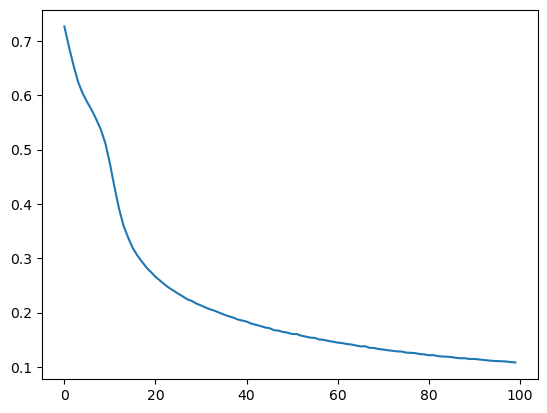

In [17]:
plt.plot(history.epoch, history.history.get('loss'))

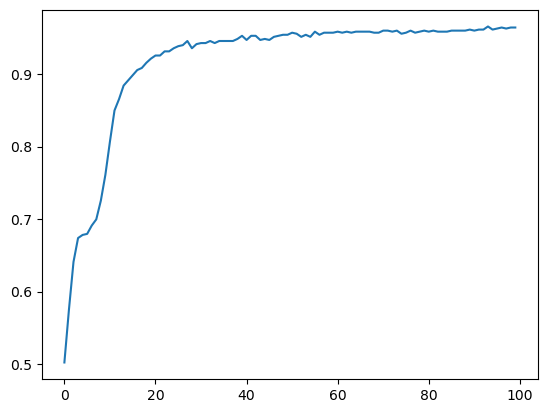

In [18]:
plt.plot(history.epoch, history.history.get('acc'))